In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import shutil
shutil.copy('/content/drive/MyDrive/FruitinAmazon.zip', '/content/FruitinAmazon.zip')
print('Zip copied from Drive!')

Zip copied from Drive!


In [ ]:
import zipfile, os

zip_path = '/content/FruitinAmazon.zip'

print('Extracting dataset...')
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/')
print('Done!')

# Set paths — these are fixed based on the zip structure
train_dir = '/content/FruitinAmazon/train'
test_dir  = '/content/FruitinAmazon/test'

print('\nTrain classes:', sorted(os.listdir(train_dir)))
print('Test  classes:', sorted(os.listdir(test_dir)))

# Count images per class
print('\n--- Image counts ---')
for split, path in [('TRAIN', train_dir), ('TEST', test_dir)]:
    for cls in sorted(os.listdir(path)):
        n = len(os.listdir(os.path.join(path, cls)))
        print(f'  {split} | {cls}: {n} images')

Extracting dataset...
Done!

Train classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Test  classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']

--- Image counts ---
  TRAIN | acai: 15 images
  TRAIN | cupuacu: 15 images
  TRAIN | graviola: 15 images
  TRAIN | guarana: 15 images
  TRAIN | pupunha: 15 images
  TRAIN | tucuma: 15 images
  TEST | acai: 5 images
  TEST | cupuacu: 5 images
  TEST | graviola: 5 images
  TEST | guarana: 5 images
  TEST | pupunha: 5 images
  TEST | tucuma: 5 images


In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from PIL import Image
from sklearn.metrics import classification_report

print(f'TensorFlow  : {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f"GPU         : {'YES - ' + gpus[0].name if gpus else 'No GPU — go Runtime > Change runtime type > T4 GPU'}")

# Fixed paths from the extracted zip
train_dir   = '/content/FruitinAmazon/train'
test_dir    = '/content/FruitinAmazon/test'
CLASS_NAMES = sorted(os.listdir(train_dir))
NUM_CLASSES = len(CLASS_NAMES)
print(f'Classes     : {CLASS_NAMES}')
print(f'Num classes : {NUM_CLASSES}')

TensorFlow  : 2.19.0
GPU         : YES - /physical_device:GPU:0
Classes     : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes : 6


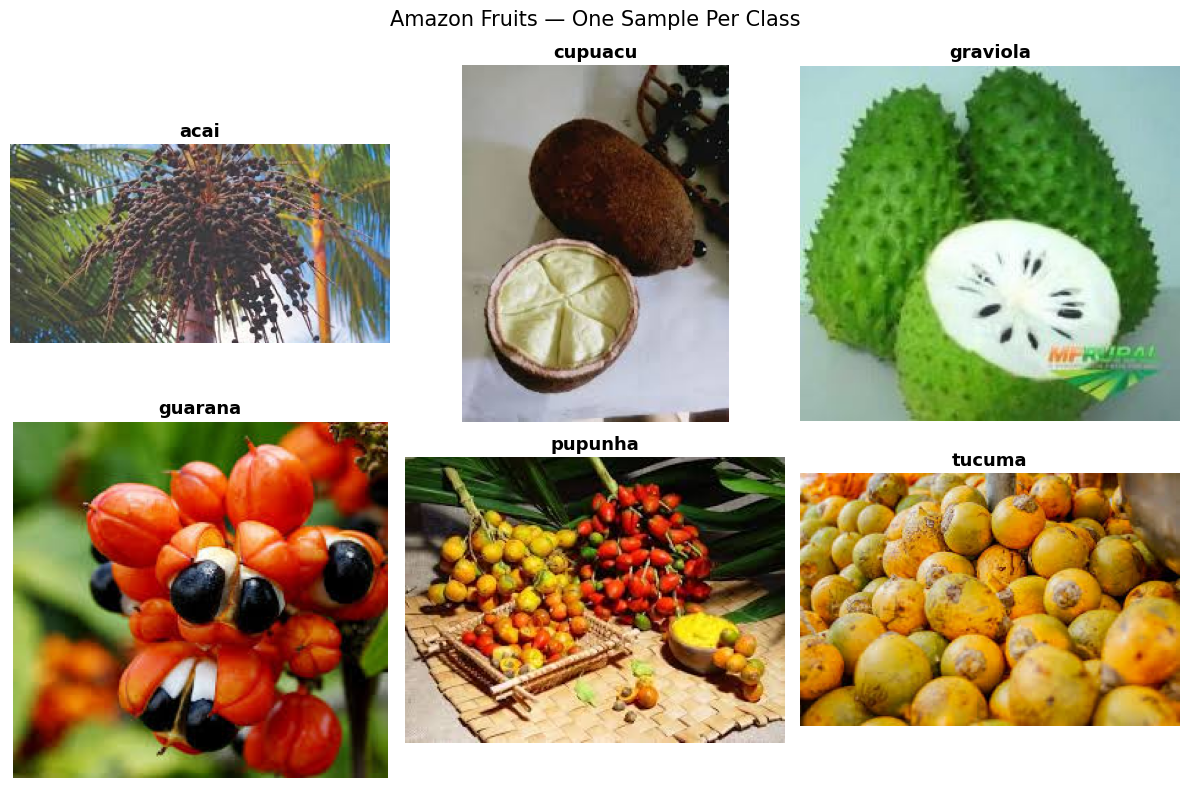


Observation:
The dataset contains 6 Amazon fruit classes: acai, cupuacu, graviola,
guarana, pupunha, and tucuma. Images vary in size, lighting, background
and angle, making it a challenging classification task for the CNN.


In [ ]:
# ── Task 1a: Display one random image per class in 2-row grid ───────────────
cols = (NUM_CLASSES + 1) // 2   # 3 columns for 6 classes
fig, axes = plt.subplots(2, cols, figsize=(cols * 4, 8))
axes = axes.flatten()

for i, class_name in enumerate(CLASS_NAMES):
    class_path = os.path.join(train_dir, class_name)
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    random_img = random.choice(images)
    img = Image.open(os.path.join(class_path, random_img))
    axes[i].imshow(img)
    axes[i].set_title(class_name, fontsize=13, fontweight='bold')
    axes[i].axis('off')

# Hide unused axes (in case of odd number of classes)
for j in range(NUM_CLASSES, len(axes)):
    axes[j].axis('off')

plt.suptitle('Amazon Fruits — One Sample Per Class', fontsize=15)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nObservation:')
print('The dataset contains 6 Amazon fruit classes: acai, cupuacu, graviola,')
print('guarana, pupunha, and tucuma. Images vary in size, lighting, background')
print('and angle, making it a challenging classification task for the CNN.')

In [ ]:
# ── Task 1b: Check and remove corrupted images ───────────────────────────────
corrupted = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if not os.path.isdir(class_path):
        continue
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        try:
            img = Image.open(img_path)
            img.verify()  # verify it is a valid image
        except (IOError, SyntaxError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f'Removed corrupted image: {img_path}')

if not corrupted:
    print('No Corrupted Images Found.')
else:
    print(f'\nTotal corrupted images removed: {len(corrupted)}')

No Corrupted Images Found.


In [ ]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
IMG_HEIGHT       = 128
IMG_WIDTH        = 128
BATCH_SIZE       = 16
VALIDATION_SPLIT = 0.2
EPOCHS           = 250

print(f'Image size       : {IMG_HEIGHT} x {IMG_WIDTH}')
print(f'Batch size       : {BATCH_SIZE}')
print(f'Validation split : {VALIDATION_SPLIT}')
print(f'Max Epochs       : {EPOCHS}')

# Normalisation layer: scale pixel values from [0,255] to [0,1]
rescale = tf.keras.layers.Rescaling(1./255)

# ── Training Dataset ─────────────────────────────────────────────────────────
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=VALIDATION_SPLIT,
    subset='training',
    seed=123
)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# ── Validation Dataset ───────────────────────────────────────────────────────
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    validation_split=VALIDATION_SPLIT,
    subset='validation',
    seed=123
)
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# ── Test Dataset ─────────────────────────────────────────────────────────────
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=123
)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

print('\nAll datasets loaded and normalised successfully!')

Image size       : 128 x 128
Batch size       : 16
Validation split : 0.2
Max Epochs       : 250
Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.

All datasets loaded and normalised successfully!


In [ ]:
# ── CNN Architecture (exactly as per Worksheet 5 specification) ──────────────
model = keras.Sequential([
    # Input
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),

    # ── Convolutional Block 1 ─────────────────────────────────────────────
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same',
                  strides=1, activation='relu'),        # Conv Layer 1
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),   # Pooling Layer 1

    # ── Convolutional Block 2 ─────────────────────────────────────────────
    layers.Conv2D(filters=32, kernel_size=(3, 3), padding='same',
                  strides=1, activation='relu'),        # Conv Layer 2
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),   # Pooling Layer 2

    # ── Fully Connected Network ───────────────────────────────────────────
    layers.Flatten(),                                   # Flatten Layer
    layers.Dense(64,  activation='relu'),               # Hidden Layer 1
    layers.Dense(128, activation='relu'),               # Hidden Layer 2

    # ── Output Layer ──────────────────────────────────────────────────────
    layers.Dense(NUM_CLASSES, activation='softmax'),    # Output (6 classes)

], name='Fruit_CNN')

model.summary()

Model: "Fruit_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Compile ───────────────────────────────────────────────────────────────────
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print('Model compiled!')
print('  Optimizer : Adam')
print('  Loss      : sparse_categorical_crossentropy')
print('  Metric    : accuracy')

Model compiled!
  Optimizer : Adam
  Loss      : sparse_categorical_crossentropy
  Metric    : accuracy


In [ ]:
# ── Callbacks ─────────────────────────────────────────────────────────────────
callbacks = [
    ModelCheckpoint(
        filepath='best_fruit_cnn.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',
        patience=20,          # stop if no improvement for 20 epochs
        restore_best_weights=True,
        verbose=1
    )
]

# ── Train ─────────────────────────────────────────────────────────────────────
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

print(f'\nTraining complete!')
print(f'Epochs trained  : {len(history.history["loss"])}')
print(f'Best val_acc    : {max(history.history["val_accuracy"])*100:.2f}%')

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - accuracy: 0.1569 - loss: 2.2199
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_fruit_cnn.keras

Epoch 1: finished saving model to best_fruit_cnn.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1806 - loss: 2.2690 - val_accuracy: 0.0000e+00 - val_loss: 2.2301
Epoch 2/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3750 - loss: 1.7302
Epoch 2: val_accuracy improved from 0.00000 to 0.66667, saving model to best_fruit_cnn.keras

Epoch 2: finished saving model to best_fruit_cnn.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3333 - loss: 1.7010 - val_accuracy: 0.6667 - val_loss: 1.4341
Epoch 3/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2500 - loss: 1.7302
Epoch 3: val_accuracy did not improve from 0.66667
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3194 - loss: 1.5410 - val_accuracy: 0.6667 - val_loss: 1.4916
Epoch 4/250
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accur

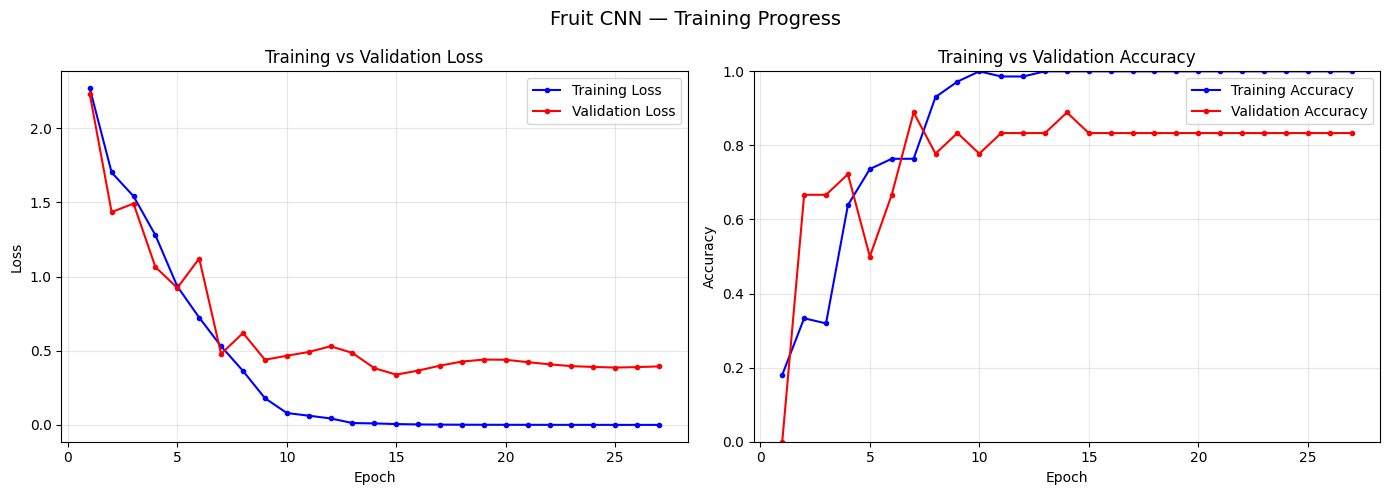

Saved: training_curves.png ✓


In [ ]:
# ── Plot Training & Validation Loss / Accuracy ────────────────────────────────
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']
ep_range   = range(1, len(train_loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ep_range, train_loss, 'b-o', markersize=3, label='Training Loss')
ax1.plot(ep_range, val_loss,   'r-o', markersize=3, label='Validation Loss')
ax1.set_title('Training vs Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(ep_range, train_acc, 'b-o', markersize=3, label='Training Accuracy')
ax2.plot(ep_range, val_acc,   'r-o', markersize=3, label='Validation Accuracy')
ax2.set_title('Training vs Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_ylim([0, 1])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Fruit CNN — Training Progress', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png ✓')

In [ ]:
test_loss, test_acc = model.evaluate(test_ds, verbose=2)

print(f"\n{'='*40}")
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_acc * 100:.2f}%')
print(f"{'='*40}")

2/2 - 1s - 363ms/step - accuracy: 0.4333 - loss: 1.2883

  Test Loss     : 1.2883
  Test Accuracy : 43.33%


In [ ]:
# ── Save model ────────────────────────────────────────────────────────────────
model.save('fruit_cnn_model.h5')
print('Model saved: fruit_cnn_model.h5 ✓')

# ── Reload model ──────────────────────────────────────────────────────────────
loaded_model = tf.keras.models.load_model('fruit_cnn_model.h5')
print('Model loaded successfully! ✓')

# ── Re-evaluate loaded model ──────────────────────────────────────────────────
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=0)
print(f'\nOriginal accuracy : {test_acc*100:.2f}%')
print(f'Loaded   accuracy : {loaded_acc*100:.2f}%')
print(f"Match             : {'YES ✓' if abs(test_acc - loaded_acc) < 1e-4 else 'NO ✗'}")

Model saved: fruit_cnn_model.h5 ✓
Model loaded successfully! ✓

Original accuracy : 43.33%
Loaded   accuracy : 43.33%
Match             : YES ✓


In [ ]:
# ── Collect all true labels and predictions ────────────────────────────────────
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

correct   = np.sum(y_true == y_pred)
incorrect = np.sum(y_true != y_pred)
print(f'Correct   : {correct}  ({correct/len(y_true)*100:.1f}%)')
print(f'Incorrect : {incorrect} ({incorrect/len(y_true)*100:.1f}%)')

Correct   : 13  (43.3%)
Incorrect : 17 (56.7%)


In [ ]:
# ── Classification Report ─────────────────────────────────────────────────────
print('Classification Report')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Classification Report
              precision    recall  f1-score   support

        acai       0.50      0.80      0.62         5
     cupuacu       0.42      1.00      0.59         5
    graviola       1.00      0.40      0.57         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.25      0.40      0.31         5

    accuracy                           0.43        30
   macro avg       0.36      0.43      0.35        30
weighted avg       0.36      0.43      0.35        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


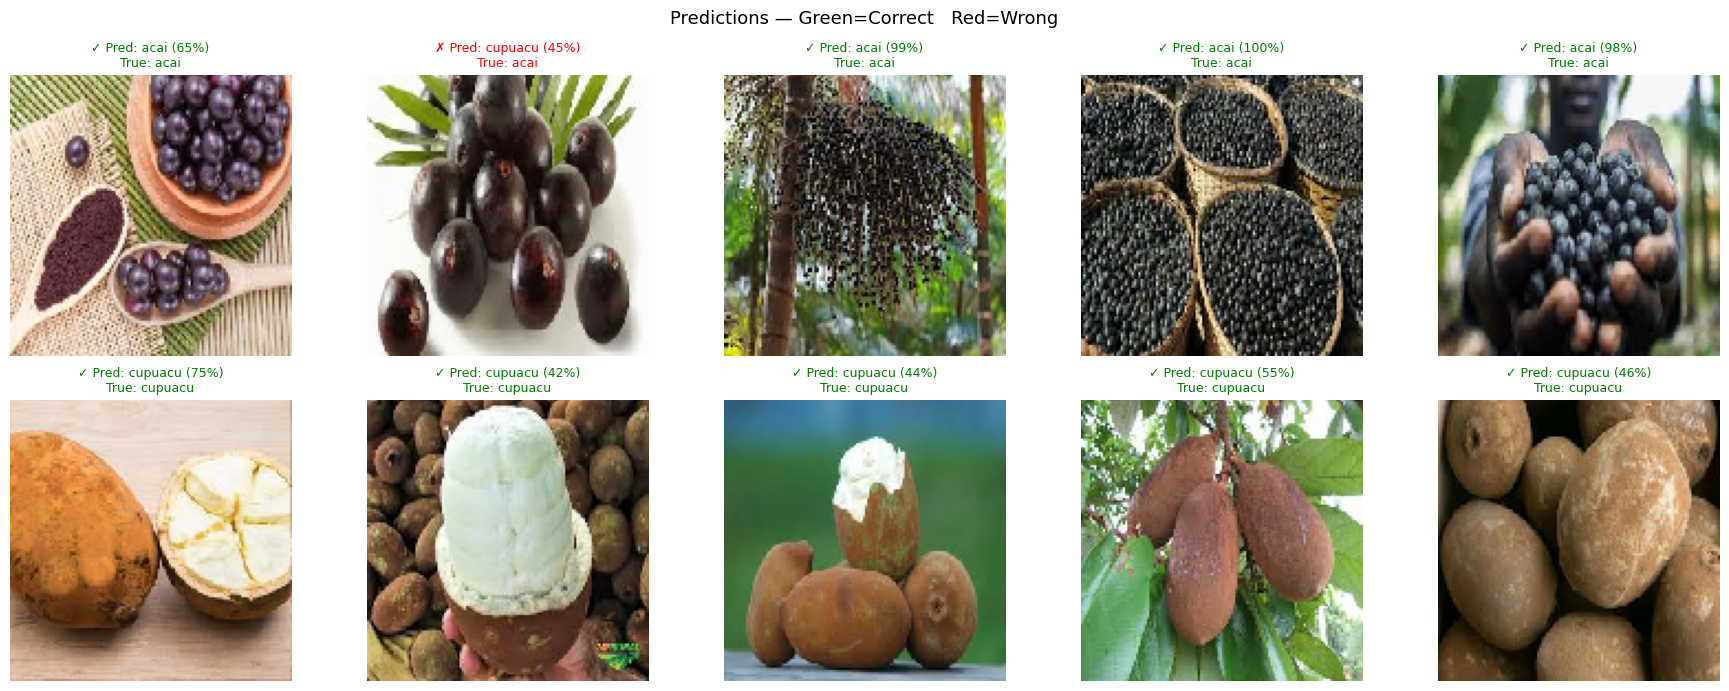

Saved: predictions_sample.png ✓


In [ ]:
# ── Visualise sample predictions (first 10 test images) ───────────────────────
sample_images, sample_labels = [], []
for images, labels in test_ds.take(1):
    sample_images = images.numpy()
    sample_labels = labels.numpy()

n_show      = min(10, len(sample_images))
preds       = loaded_model.predict(sample_images[:n_show], verbose=0)
pred_labels = np.argmax(preds, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i in range(n_show):
    pred   = pred_labels[i]
    truth  = sample_labels[i]
    conf   = preds[i][pred] * 100
    colour = 'green' if pred == truth else 'red'
    mark   = '✓' if pred == truth else '✗'

    axes[i].imshow(sample_images[i])
    axes[i].set_title(
        f"{mark} Pred: {CLASS_NAMES[pred]} ({conf:.0f}%)\nTrue: {CLASS_NAMES[truth]}",
        color=colour, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Predictions — Green=Correct   Red=Wrong', fontsize=13)
plt.tight_layout()
plt.savefig('predictions_sample.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: predictions_sample.png ✓')